# Supervised Fine-Tuning (SFT) with Qwen 0.5B for Mathematical Reasoning

This notebook demonstrates supervised fine-tuning of a small Qwen model using the SFT class from simple_rl.

## Features:
- Uses simple_rl.algorithms.SFT class
- Downloads and loads Qwen 0.5B model
- Uses GSM8K math dataset for training
- Standard supervised learning with cross-entropy loss
- Custom prompt formatting for math problems
- Tracks training metrics
- Saves checkpoints

## 1. Import Libraries

In [1]:
import torch
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Import SFT class
from simple_rl.algorithms import SFT

# Import reward functions for evaluation
from simple_rl.rewards.simple_reward import (
    extract_answer_from_model_output,
    extract_single_number,
    correctness_reward,
    format_reward,
)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    torch.mps.manual_seed(42)
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## 2. Configuration

In [2]:
# Model name
MODEL_NAME = "Qwen/Qwen2.5-0.5B"

# System prompt for formatting
SYSTEM_PROMPT = """
Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
"""

# SFT Configuration
sft_config = {
    "model": {
        "model_name": MODEL_NAME,
        "max_length": 1024,
        "device": "auto",  # Auto-detect
    },
    "training": {
        "batch_size": 4,
        "learning_rate": 5e-5,
        "num_epochs": 3,
        "gradient_accumulation_steps": 4,
        "max_grad_norm": 1.0,
        "warmup_steps": 100,
    },
    "logging": {
        "log_interval": 50,
        "save_interval": 500,
    },
    "validation": {
        "enabled": True,
        "interval": 200,
        "num_samples": 20,
    },
    "wandb": {
        "enabled": False,
    }
}

print("SFT Configuration:")
print(json.dumps(sft_config, indent=2))

SFT Configuration:
{
  "model": {
    "model_name": "Qwen/Qwen2.5-0.5B",
    "max_length": 1024,
    "device": "auto"
  },
  "training": {
    "batch_size": 4,
    "learning_rate": 5e-05,
    "num_epochs": 3,
    "gradient_accumulation_steps": 4,
    "max_grad_norm": 1.0,
    "warmup_steps": 100
  },
  "logging": {
    "log_interval": 50,
    "save_interval": 500
  },
  "validation": {
    "enabled": true,
    "interval": 200,
    "num_samples": 20
  },
  "wandb": {
    "enabled": false
  }
}


## 3. Load and Prepare Dataset

In [ ]:
# Import GSM8K dataset utilities
from simple_rl.evaluation.gsm8k import load_gsm8k_dataset, prepare_gsm8k_for_sft

# Load GSM8K dataset splits
dataset_train, dataset_val, dataset_test = load_gsm8k_dataset(
    train_split="train[:2000]",
    val_split="test[200:1200]",
    test_split="test[:200]"
)

# Prepare data in SFT format (prompts and completions)
train_data = prepare_gsm8k_for_sft(dataset_train, SYSTEM_PROMPT)
val_data = prepare_gsm8k_for_sft(dataset_val, SYSTEM_PROMPT)
test_data = prepare_gsm8k_for_sft(dataset_test, SYSTEM_PROMPT)

# Show stats
print(f'\nTraining samples: {len(train_data["prompts"])}')
print(f'Validation samples: {len(val_data["prompts"])}')
print(f'Test samples: {len(test_data["prompts"])}')

# Show example
print(f'\nExample prompt:\n{train_data["prompts"][0]}')
print(f'\nExample completion:\n{train_data["completions"][0][:200]}...')

## 4. Initialize SFT

In [4]:
# Initialize SFT
print("Initializing SFT...")
sft = SFT(config=sft_config, use_wandb=False)

print("\n✓ SFT ready for training!")

Initializing SFT...
Loading tokenizer: Qwen/Qwen2.5-0.5B


`torch_dtype` is deprecated! Use `dtype` instead!


Loading model: Qwen/Qwen2.5-0.5B
✓ SFT initialized with model: Qwen/Qwen2.5-0.5B
  Total parameters: 494,032,768
  Device: mps

✓ SFT ready for training!


## 5. Training

In [5]:
# Train the model
results = sft.train(
    train_data=train_data,
    val_data=val_data,
    num_episodes=sft_config['training']['num_epochs']
)

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Total time: {results['total_time']:.2f} seconds ({results['total_time']/60:.2f} minutes)")
print(f"Final loss: {results['final_loss']:.4f}")

Starting SFT training for 3 epochs...
Batch size: 4
Gradient accumulation steps: 4
Effective batch size: 16


Epoch 1/3:  40%|████      | 200/500 [05:44<08:35,  1.72s/it, loss=0.4857, lr=2.50e-05, tok/s=410]


Step 50 | Loss: 0.4857 | LR: 2.50e-05 | Tokens/s: 410


Epoch 1/3:  80%|████████  | 400/500 [12:13<02:58,  1.79s/it, loss=0.6290, lr=5.00e-05, tok/s=561]


Step 100 | Loss: 0.6290 | LR: 5.00e-05 | Tokens/s: 561


...


Step 300 | Loss: 0.1011 | LR: 1.36e-05 | Tokens/s: 408


Epoch 3/3:  80%|████████  | 400/500 [11:39<03:04,  1.84s/it, loss=0.1638, lr=4.55e-06, tok/s=397]


Step 350 | Loss: 0.1638 | LR: 4.55e-06 | Tokens/s: 397


Epoch 3/3: 100%|██████████| 500/500 [14:32<00:00,  1.75s/it, loss=0.0765, lr=0.00e+00, tok/s=444]


Epoch 3 completed in 872.89s | Avg Loss: 0.0338
Training complete!
Total training time: 2744.15 seconds (45.74 minutes)
Total steps: 375

TRAINING COMPLETE
Total time: 2744.15 seconds (45.74 minutes)
Final loss: 0.0765


## 6. Evaluation Functions

In [6]:
def evaluate_on_gsm8k(
    sft_instance,
    test_prompts,
    test_answers,
    num_samples,
    max_new_tokens=128,
    temperature=1.0,
    model_name="Model"
):
    """
    Evaluate a model on GSM8K test set.
    """
    from tqdm import tqdm
    
    # Sample subset if needed
    if num_samples < len(test_prompts):
        indices = np.random.choice(len(test_prompts), num_samples, replace=False)
        eval_prompts = [test_prompts[i] for i in indices]
        eval_answers = [test_answers[i] for i in indices]
    else:
        eval_prompts = test_prompts
        eval_answers = test_answers
    
    # Metrics tracking
    correct_exact = 0
    correct_numeric = 0
    format_compliant = 0
    total_format_score = 0.0
    total_correctness_score = 0.0
    
    results = []
    
    print(f"\nEvaluating {model_name} on {len(eval_prompts)} GSM8K problems...")
    print("=" * 60)
    
    # Generate completions
    completions = sft_instance.generate(
        prompts=eval_prompts,
        max_new_tokens=max_new_tokens,
        temperature=temperature
    )
    
    for prompt, completion, correct_answer in tqdm(zip(eval_prompts, completions, eval_answers), 
                                                     total=len(eval_prompts), desc="Evaluating"):
        # Extract model's answer
        model_answer = extract_answer_from_model_output(completion)
        
        # Check correctness
        is_exact = False
        is_numeric = False
        
        if model_answer:
            # Exact match
            if model_answer == correct_answer:
                correct_exact += 1
                is_exact = True
                is_numeric = True
            else:
                # Numeric equivalence
                model_num = extract_single_number(model_answer)
                correct_num = extract_single_number(correct_answer)
                if model_num is not None and correct_num is not None:
                    if abs(model_num - correct_num) < 0.01:
                        correct_numeric += 1
                        is_numeric = True
        
        # Check format compliance
        fmt_score = format_reward(completion)
        total_format_score += fmt_score
        
        # Full format compliance
        if all(tag in completion for tag in ["<reasoning>", "</reasoning>", "<answer>", "</answer>"]):
            format_compliant += 1
        
        # Calculate correctness reward
        correct_score = correctness_reward(completion, correct_answer)
        total_correctness_score += correct_score
        
        # Store result
        results.append({
            'prompt': prompt[:50] + "...",
            'model_answer': model_answer,
            'correct_answer': correct_answer,
            'is_exact': is_exact,
            'is_numeric': is_numeric,
            'format_score': fmt_score,
            'correctness_score': correct_score
        })
    
    # Calculate metrics
    n = len(eval_prompts)
    metrics = {
        'exact_accuracy': correct_exact / n * 100,
        'numeric_accuracy': correct_numeric / n * 100,
        'format_compliance': format_compliant / n * 100,
        'avg_format_score': total_format_score / n,
        'avg_correctness_score': total_correctness_score / n,
        'num_evaluated': n,
        'results': results
    }
    
    # Print summary
    print(f"\n{model_name} Evaluation Results:")
    print(f"  Exact Match Accuracy: {metrics['exact_accuracy']:.1f}%")
    print(f"  Numeric Accuracy: {metrics['numeric_accuracy']:.1f}%")
    print(f"  Format Compliance: {metrics['format_compliance']:.1f}%")
    print(f"  Avg Format Score: {metrics['avg_format_score']:.3f}")
    print(f"  Avg Correctness Score: {metrics['avg_correctness_score']:.3f}")
    
    return metrics


def demonstrate_model_responses(
    sft_instance,
    test_prompts,
    test_answers,
    num_examples,
    max_new_tokens=128,
    temperature=1.0,
    title="MODEL RESPONSE EXAMPLES"
):
    """
    Demonstrate actual model responses on a few examples.
    """
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    
    # Select random examples
    indices = np.random.choice(len(test_prompts), min(num_examples, len(test_prompts)), replace=False)
    demo_prompts = [test_prompts[i] for i in indices]
    demo_answers = [test_answers[i] for i in indices]
    
    # Generate completions
    completions = sft_instance.generate(
        prompts=demo_prompts,
        max_new_tokens=max_new_tokens,
        temperature=temperature
    )
    
    results = []
    
    for i, (prompt, completion, correct_answer) in enumerate(zip(demo_prompts, completions, demo_answers), 1):
        print(f"\nExample {i}:")
        print(f"Problem: {prompt[:150]}...")
        print(f"Correct Answer: {correct_answer}")
        print("-" * 40)
        
        print(f"Model Response:\n{completion[:400]}...")
        
        # Extract and check answer
        model_answer = extract_answer_from_model_output(completion)
        print(f"\nExtracted Answer: {model_answer if model_answer else 'None (format issue)'}")
        
        # Check correctness
        is_correct = False
        if model_answer:
            if model_answer == correct_answer:
                print("Status: ✓ CORRECT (exact match)")
                is_correct = True
            else:
                model_num = extract_single_number(model_answer)
                correct_num = extract_single_number(correct_answer)
                if model_num and correct_num and abs(model_num - correct_num) < 0.01:
                    print("Status: ✓ CORRECT (numeric)")
                    is_correct = True
                else:
                    print("Status: ✗ INCORRECT")
        else:
            print("Status: ✗ NO ANSWER")
        
        # Check format
        has_format = all(tag in completion for tag in ["<reasoning>", "</reasoning>", "<answer>", "</answer>"])
        print(f"Format Compliance: {'Yes' if has_format else 'No'}")
        
        results.append({
            'prompt': prompt[:100],
            'model_answer': model_answer,
            'correct_answer': correct_answer,
            'is_correct': is_correct,
            'has_format': has_format
        })
    
    # Summary
    correct_count = sum(r['is_correct'] for r in results)
    format_count = sum(r['has_format'] for r in results)
    print(f"\n{'-'*60}")
    print(f"Summary: {correct_count}/{len(results)} correct, {format_count}/{len(results)} with proper format")
    
    return results

print("Evaluation functions defined")

Evaluation functions defined


## 7. Visualize Training Metrics

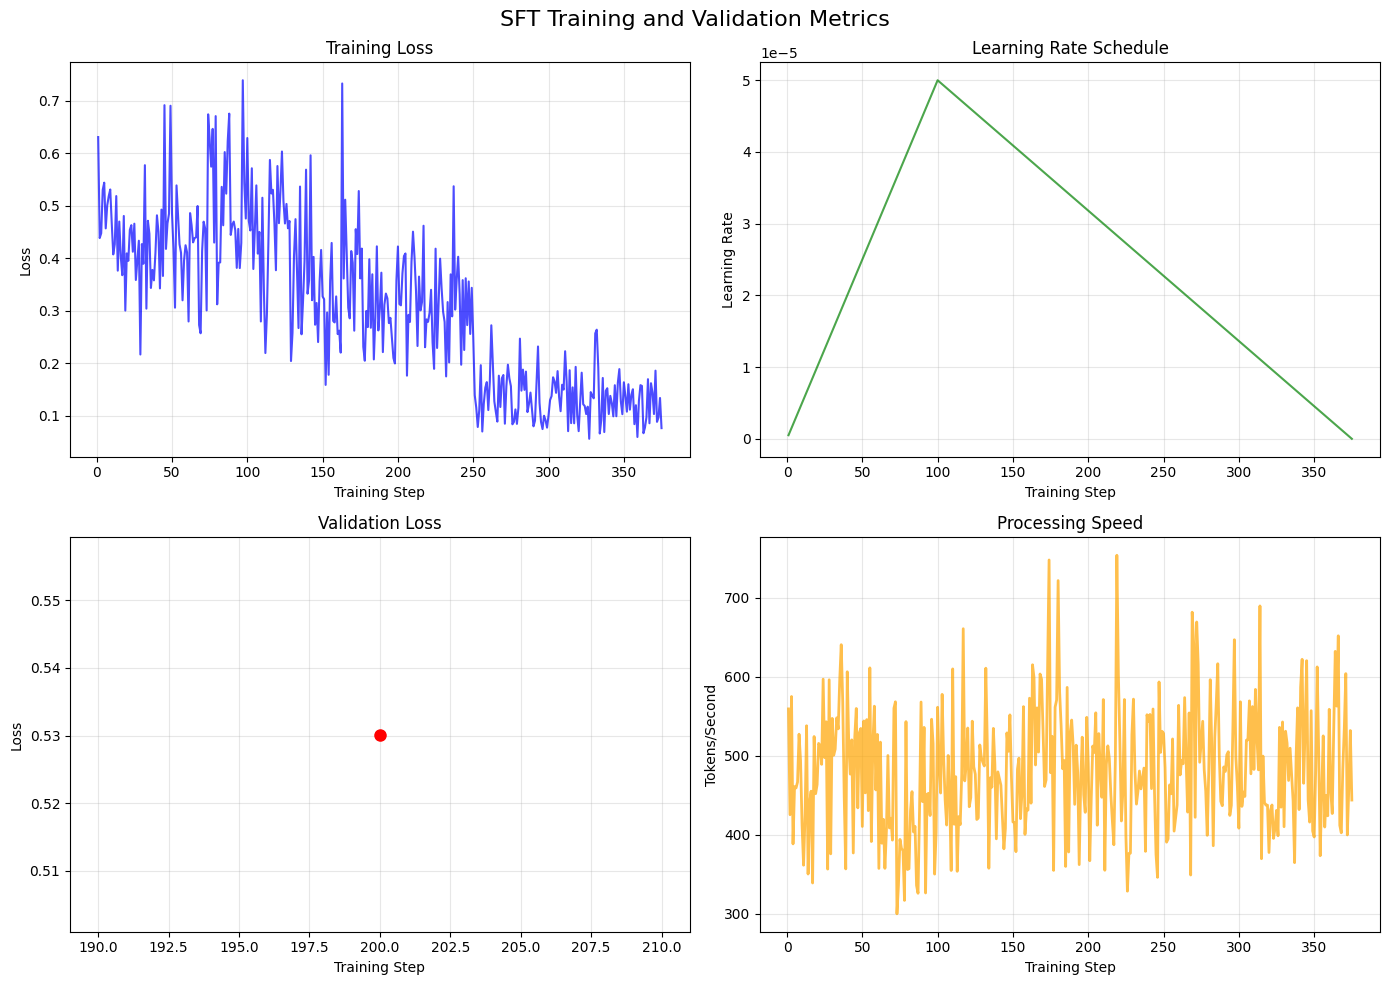


TRAINING SUMMARY

Training Performance:
  Final Loss: 0.0765
  Initial Loss: 0.6309
  Loss Reduction: 0.5543
  Average Loss (last 10 steps): 0.1247
  Average Processing Speed: 481.1 tokens/second

Validation Results:
  Final Validation Loss: 0.5301
  Initial Validation Loss: 0.5301



In [7]:
# Extract metrics from results
training_metrics = results['training_metrics']
validation_metrics = results['validation_metrics']

# Plot training and validation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SFT Training and Validation Metrics', fontsize=16)

# Training Loss
axes[0, 0].plot(training_metrics["step"], training_metrics["loss"], 'b-', alpha=0.7)
axes[0, 0].set_xlabel('Training Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# Learning Rate
axes[0, 1].plot(training_metrics["step"], training_metrics["learning_rate"], 'g-', alpha=0.7)
axes[0, 1].set_xlabel('Training Step')
axes[0, 1].set_ylabel('Learning Rate')
axes[0, 1].set_title('Learning Rate Schedule')
axes[0, 1].grid(True, alpha=0.3)

# Validation Loss
if validation_metrics["step"]:
    axes[1, 0].plot(validation_metrics["step"], validation_metrics["loss"], 
                    'ro-', markersize=8)
    axes[1, 0].set_xlabel('Training Step')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].set_title('Validation Loss')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No validation data', ha='center', va='center')
    axes[1, 0].set_title('Validation Loss')

# Tokens per Second
axes[1, 1].plot(training_metrics["step"], training_metrics["tokens_per_second"], 
                'orange', alpha=0.7, linewidth=2)
axes[1, 1].set_xlabel('Training Step')
axes[1, 1].set_ylabel('Tokens/Second')
axes[1, 1].set_title('Processing Speed')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"\nTraining Performance:")
print(f"  Final Loss: {training_metrics['loss'][-1]:.4f}")
print(f"  Initial Loss: {training_metrics['loss'][0]:.4f}")
print(f"  Loss Reduction: {training_metrics['loss'][0] - training_metrics['loss'][-1]:.4f}")
print(f"  Average Loss (last 10 steps): {np.mean(training_metrics['loss'][-10:]):.4f}")
print(f"  Average Processing Speed: {np.mean(training_metrics['tokens_per_second']):.1f} tokens/second")

if validation_metrics["step"]:
    print(f"\nValidation Results:")
    print(f"  Final Validation Loss: {validation_metrics['loss'][-1]:.4f}")
    print(f"  Initial Validation Loss: {validation_metrics['loss'][0]:.4f}")
    if len(validation_metrics['loss']) > 1:
        print(f"  Validation Loss Reduction: {validation_metrics['loss'][0] - validation_metrics['loss'][-1]:.4f}")

print("\n" + "="*60)

## 8. Final Evaluation on Test Set

In [8]:
# Extract answers from test data for evaluation
test_prompts = test_data["prompts"]
# Extract just the final answer from completions
test_answers = []
for completion in test_data["completions"]:
    answer = extract_answer_from_model_output(completion)
    test_answers.append(answer if answer else "")

# Evaluate on full test set
final_test_metrics = evaluate_on_gsm8k(
    sft,
    test_prompts,
    test_answers,
    len(test_prompts),
    model_name="Final SFT Model"
)


Evaluating Final SFT Model on 200 GSM8K problems...


Evaluating: 100%|██████████| 200/200 [00:00<00:00, 418593.21it/s]


Final SFT Model Evaluation Results:
  Exact Match Accuracy: 18.0%
  Numeric Accuracy: 0.0%
  Format Compliance: 53.0%
  Avg Format Score: 0.935
  Avg Correctness Score: 0.360


## 9. Demonstrate Final Model Responses

In [9]:
# Show example responses from final model
demonstrate_model_responses(
    sft,
    test_prompts,
    test_answers,
    5,
    title="FINAL MODEL RESPONSE EXAMPLES"
)


FINAL MODEL RESPONSE EXAMPLES

Example 1:
Problem: Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
When Freda cooks canned tomatoes into sauce, they lose half thei...
Correct Answer: 12
----------------------------------------
Model Response:
<reasoning>
Let m be the number of tomatoes that Freda used.
Since each 16ounce can of tomatoes contains 3 tomatoes, then Freda used 3 * 16 = <<3*16=48>>48 tomatoes.
To make 32 ounces of sauce, Freda used 32 / 48 = <<32/48=0.75>>0.75 of a can of tomatoes.
Thus, she used 0.75 * 3 = <<0.75*3=2.25>>2.25 tomatoes....

Extracted Answer: None (format issue)
Status: ✗ NO ANSWER
Format Compliance: No

Example 2:
Problem: Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
A classroom has a whiteboard which is shared between the 4 teach...
Correct Answer: 24
----------------------------------------
Model Response:
<reasoning>
Each teacher uses the whiteboard 2 x 4 = <<2*4=8>>8 times p

[{'prompt': 'Respond in the following format:\n\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\nWhen Freda coo',
  'model_answer': None,
  'correct_answer': '12',
  'is_correct': False,
  'has_format': False},
 {'prompt': 'Respond in the following format:\n\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\nA classroom ha',
  'model_answer': '24',
  'correct_answer': '24',
  'is_correct': True,
  'has_format': True},
 {'prompt': 'Respond in the following format:\n\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\nJohn collects ',
  'model_answer': '48',
  'correct_answer': '360',
  'is_correct': False,
  'has_format': True},
 {'prompt': 'Respond in the following format:\n\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\nJosh decides t',
  'model_answer': None,
  'correct_answer': '70000',
  'is_correct': False,
  'has_format': False},
 {'prompt': 'Respond in the following format:\n\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\nBilly is